In [91]:
import torch
import torchaudio
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
from typing import Tuple, List
from tqdm.auto import tqdm, trange
from IPython import display

import librosa
import librosa.display
from IPython.display import Audio

### Введение в обработку аудио

#### Почему не всегда удобно работать с сырым аудиосигналом

Аудиосигнал - это последовательность амплитудных отсчётов во времени. Теоретически такие данные можно подавать напрямую в нейросеть, но на практике это не самый удобный вариант:

1. **Высокая размерность.** Даже короткий сигнал содержит много отсчётов.
2. **Сложная временная структура.** В сигнале одновременно важны и короткие локальные паттерны, и более длинные зависимости.
3. **Частотная информация скрыта неявно.** По самому временному ряду не так удобно понять, какие частоты присутствуют в сигнале.

**Мел-спектрограмма**

обычная спектрограмма информативна, но она не отражает особенности человеческого слуха. Поэтому в задачах распознавания звука часто используют мел‑спектрограммы.

В этом случае:
- частотная ось переводится в мел‑шкалу, более близкую к тому, как человек различает высоту звука;
- величины энергии обычно переводят в децибелы, то есть используют логарифмический масштаб.

Мел‑спектрограммы удобны тем, что:
- уменьшают размерность признаков;
- подчёркивают перцептивно важные частоты;
- дают двумерное «изображение», с которым особенно хорошо работают сверточные нейросети.




### UrbanSound8K

Мы будем работать с датасетом **UrbanSound8K**. В нём содержится 8732 размеченных аудиофрагмента городских звуков длительностью не более 4 секунд. В датасете 10 классов:
`air_conditioner`, `car_horn`, `children_playing`, `dog_bark`, `drilling`, `engine_idling`, `gun_shot`, `jackhammer`, `siren`, `street_music`.

https://urbansounddataset.weebly.com/urbansound8k.html

Структура датасета:
```
UrbanSound8K/
├── audio/
│   ├── fold1/
│   ├── fold2/
│   └── ...
└── metadata/
    └── UrbanSound8K.csv
```

**Особенность датасета**

UrbanSound8K уже разбит авторами на 10 fold'ов, и в этой задаче нужно использовать именно их.

Для этого датасета не стоит делать случайное разбиение, потому что фрагменты, относящиеся к одному и тому же исходному событию, могут оказаться и в обучении, и в тесте. В таком случае качество будет завышено и перестанет честно отражать способность модели обобщать на новые данные.

Поэтому здесь используется следующая схема:

- для быстрых экспериментов: `folds 1–8 -> train`, `9 -> val`, `10 -> test`
- для финальной оценки: один прогон 10-fold cross-validation по official folds.

Случайно перераспределять примеры между fold'ами не нужно.  

In [85]:
DATASET_PATH = "archive"

# Загрузим метаданные
metadata = pd.read_csv(os.path.join(DATASET_PATH, "UrbanSound8K.csv"))

print(f"Всего примеров: {len(metadata)}")
print("\nРаспределение по классам:")
print(metadata["class"].value_counts().sort_index())
print("\nРаспределение по fold'ам:")
print(metadata["fold"].value_counts().sort_index())

Всего примеров: 8732

Распределение по классам:
class
air_conditioner     1000
car_horn             429
children_playing    1000
dog_bark            1000
drilling            1000
engine_idling       1000
gun_shot             374
jackhammer          1000
siren                929
street_music        1000
Name: count, dtype: int64

Распределение по fold'ам:
fold
1     873
2     888
3     925
4     990
5     936
6     823
7     838
8     806
9     816
10    837
Name: count, dtype: int64


Сначала посмотрим, как выглядят один и тот же аудиофрагмент в виде волновой формы, обычной спектрограммы и мел-спектрограммы.

Sample: 207216-2-0-43.wav
Class: children_playing
Fold: 7



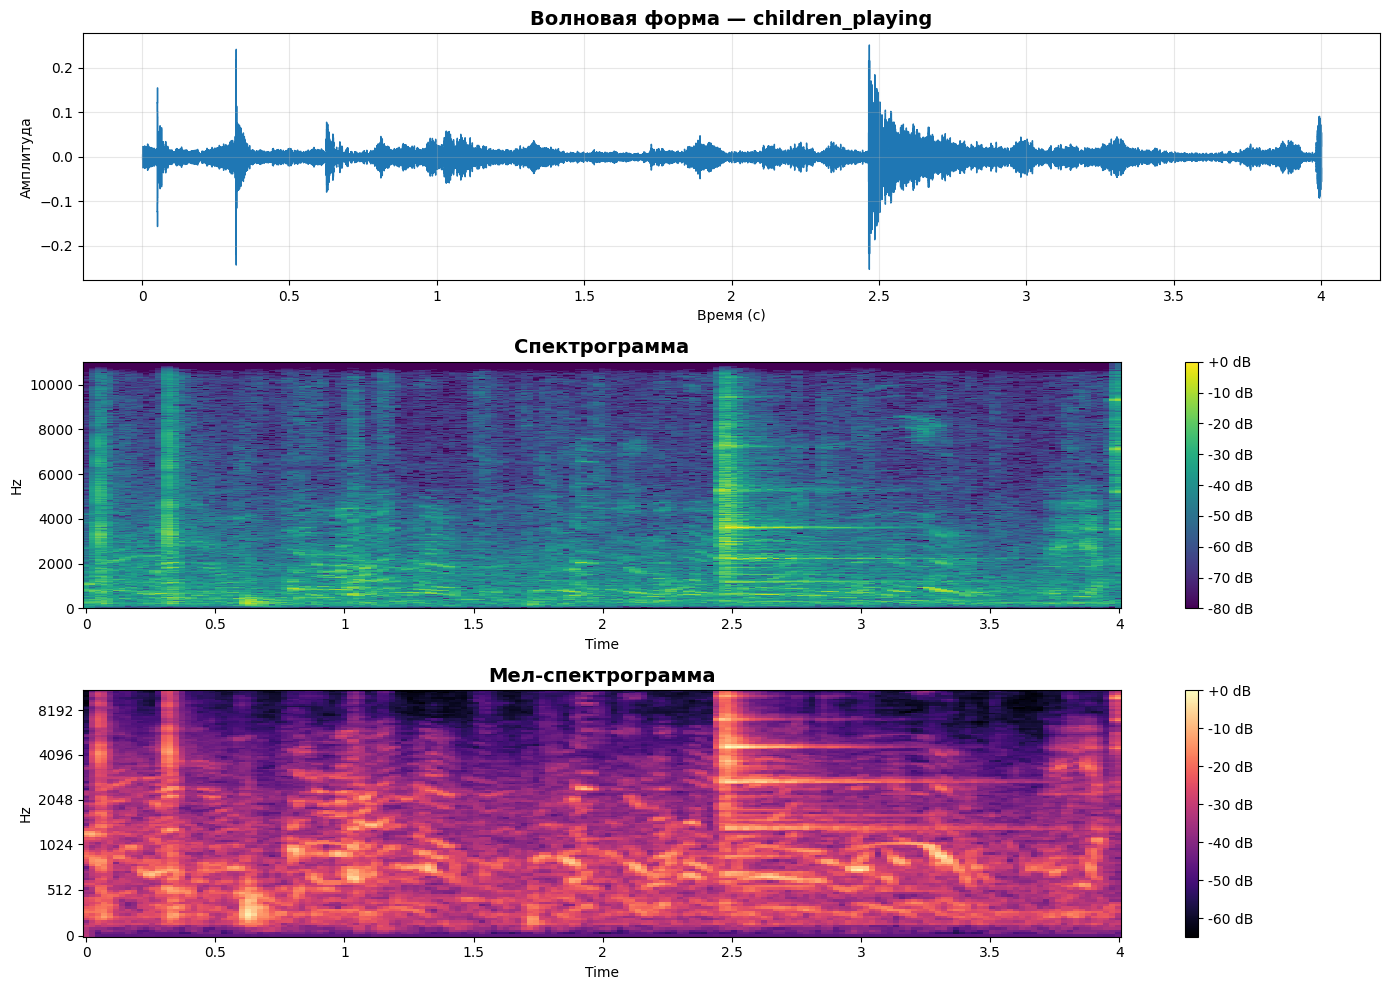

In [16]:
def plot_waveform_and_spectrogram(audio_path, class_name):
    y, sr = librosa.load(audio_path, sr=22050)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title(f"Волновая форма — {class_name}", fontsize=14, fontweight="bold")
    axes[0].set_xlabel("Время (с)")
    axes[0].set_ylabel("Амплитуда")
    axes[0].grid(alpha=0.3)

    D = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
    img1 = librosa.display.specshow(
        S_db, sr=sr, x_axis="time", y_axis="hz", ax=axes[1], cmap="viridis"
    )
    axes[1].set_title("Спектрограмма", fontsize=14, fontweight="bold")
    fig.colorbar(img1, ax=axes[1], format="%+2.0f dB")

    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    img2 = librosa.display.specshow(
        mel_spec_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[2], cmap="magma"
    )
    axes[2].set_title("Мел-спектрограмма", fontsize=14, fontweight="bold")
    fig.colorbar(img2, ax=axes[2], format="%+2.0f dB")

    plt.tight_layout()
    plt.show()
    return y, sr


random_idx = np.random.randint(0, len(metadata))
sample = metadata.iloc[random_idx]

audio_path = os.path.join(DATASET_PATH, f"fold{sample.fold}", sample.slice_file_name)
print(f"Sample: {sample.slice_file_name}")
print(f"Class: {sample['class']}")
print(f"Fold: {sample.fold}\n")

y, sr = plot_waveform_and_spectrogram(audio_path, sample["class"])
Audio(y, rate=sr)

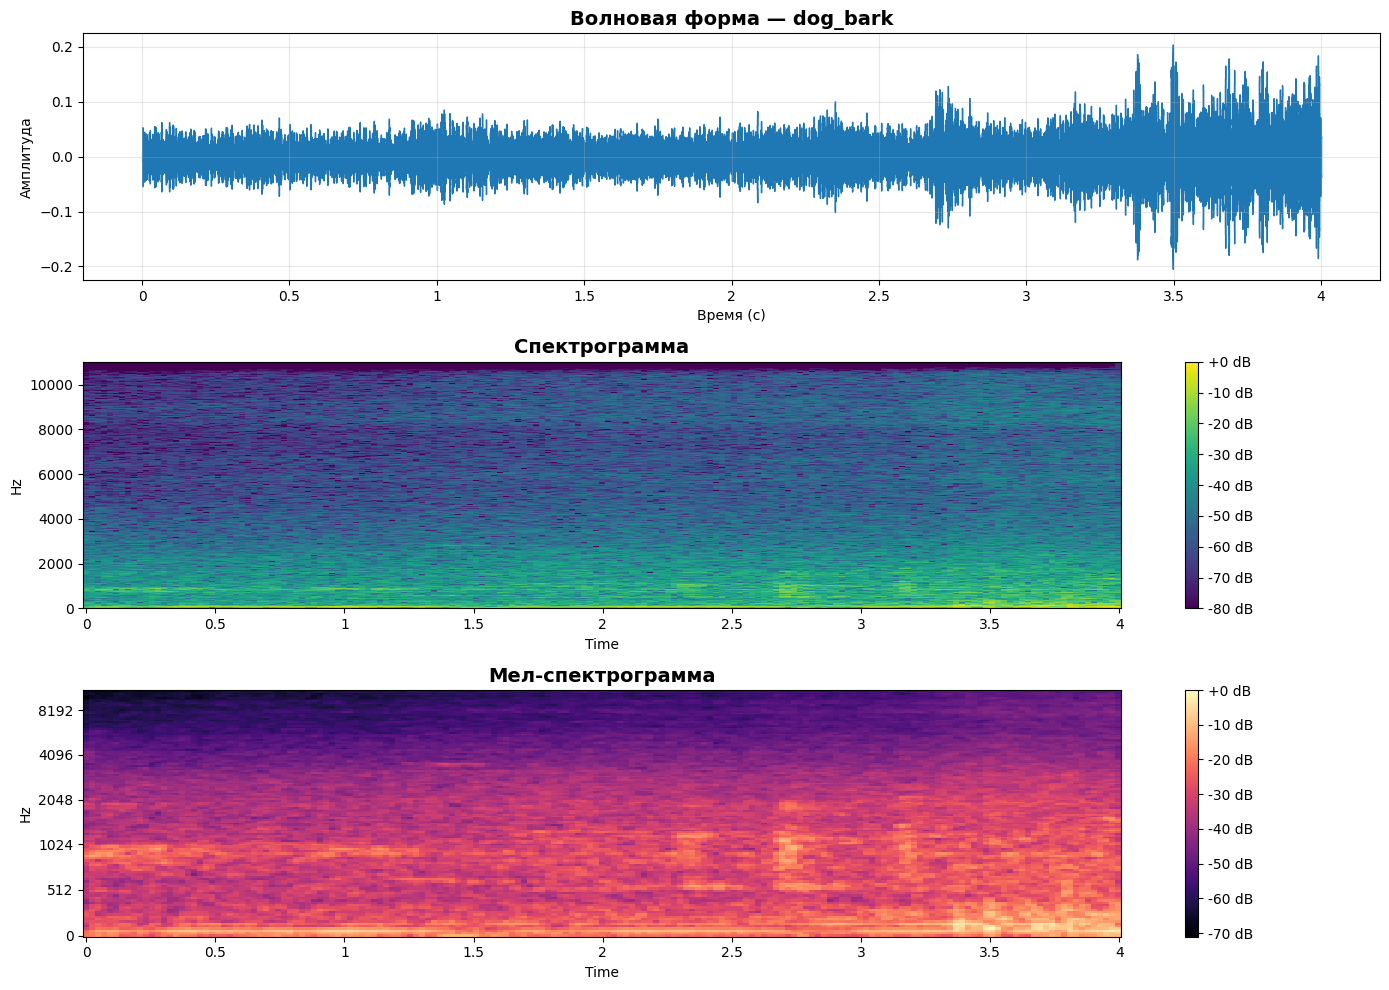

In [17]:
target_class = 'dog_bark'

class_samples = metadata[metadata['class'] == target_class]
sample = class_samples.sample(1).iloc[0]

audio_path = os.path.join(DATASET_PATH,  f'fold{sample.fold}', sample.slice_file_name)
y, sr = plot_waveform_and_spectrogram(audio_path, target_class)

Audio(y, rate=sr)

# Подготовка датасет к обучению

фиксируем единое отображение классов в числовые метки при помощи `LabelEncoder`.
Это важно, чтобы все модели (Random Forest и обе CNN) использовали одинаковый порядок
классов и их можно было корректно сравнивать.

In [86]:
# Единый LabelEncoder
ALL_CLASSES = sorted(metadata["class"].unique())
global_label_encoder = LabelEncoder()
global_label_encoder.fit(ALL_CLASSES)

print(f"Классы ({len(global_label_encoder.classes_)}):")
print(list(global_label_encoder.classes_))

Классы (10):
[np.str_('air_conditioner'), np.str_('car_horn'), np.str_('children_playing'), np.str_('dog_bark'), np.str_('drilling'), np.str_('engine_idling'), np.str_('gun_shot'), np.str_('jackhammer'), np.str_('siren'), np.str_('street_music')]


In [87]:
metadata

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.000000,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.500000,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.500000,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.000000,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.500000,72.500000,1,5,2,children_playing
...,...,...,...,...,...,...,...,...
8727,99812-1-2-0.wav,99812,159.522205,163.522205,2,7,1,car_horn
8728,99812-1-3-0.wav,99812,181.142431,183.284976,2,7,1,car_horn
8729,99812-1-4-0.wav,99812,242.691902,246.197885,2,7,1,car_horn
8730,99812-1-5-0.wav,99812,253.209850,255.741948,2,7,1,car_horn


Класс `UrbanSoundDataset` формирует PyTorch‑датасет.
Для каждого объекта:
- по `slice_file_name` и `fold` находится путь к аудиофайлу;
- загружается аудиосигнал заданной длины (`target_length` секунд при частоте дискретизации `sr`);
- по сигналу считается нормализованная мел-спектрограмма размерности `(n_mels, T)`;
- при необходимости спектрограмма кэшируется на диск для ускорения последующих запусков;
- строковый класс из метаданных преобразуется в числовую метку через общий `LabelEncoder`.

В методе `__getitem__` датасет по индексу возвращает пару (мел-спектрограмма, метка класса).
При включённом флаге `augment` к мел-спектрограмме применяются простые аугментации
(добавление шума, зануление случайных полос по частоте, изменение громкости и сдвиг по времени),
что помогает уменьшить переобучение и сделать модель устойчивее.

In [20]:
class UrbanSoundDataset(Dataset):
    def __init__(
        self,
        metadata,
        dataset_path,
        label_encoder,
        target_length=4,
        sr=22050,
        n_mels=128,
        augment=False,
        cache_dir=None, 
    ):
        self.metadata = metadata.reset_index(drop=True)
        self.dataset_path = dataset_path
        self.label_encoder = label_encoder
        self.target_length = target_length
        self.sr = sr
        self.n_mels = n_mels
        self.augment = augment
        self.cache_dir = cache_dir
        self.target_s = int(self.target_length * self.sr)

        if self.cache_dir:
            os.makedirs(self.cache_dir, exist_ok=True)
        
        self.mels = []
        self.labels = []
        self._prepare_data()
    
    def _prepare_data(self):
        """кеширование + прогресс-бар"""
        for idx in tqdm(range(len(self.metadata)), desc="Preparing mel-spectrograms"):
            cache_path = None
            if self.cache_dir:
                cache_path = os.path.join(self.cache_dir, f"{idx}.pt")
                if os.path.exists(cache_path):
                    mel = torch.load(cache_path)
                    self.mels.append(mel)
                    label = self.label_encoder.transform(
                        [self.metadata.iloc[idx]['class']]
                    )[0]
                    self.labels.append(label)
                    continue
            
            row = self.metadata.iloc[idx]
            fold = row['fold']          
            file_name = row['slice_file_name']
            file_path = os.path.join(self.dataset_path, f"fold{fold}", file_name)

            if not os.path.exists(file_path):
                print(f"[WARN] File not found: {file_path}, skip")
                continue

            y = self._load_audio(file_path)
            mel = self._extract_mel_spectrogram(y)
            mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
            
            if cache_path:
                torch.save(mel, cache_path)
            
            self.mels.append(mel)
            label = self.label_encoder.transform([row['class']])[0]
            self.labels.append(label)
        
        self.labels = torch.tensor(self.labels, dtype=torch.long)
    
    def _load_audio(self, file_path):
        zvuk, _ = librosa.load(file_path, sr=self.sr)
        if len(zvuk) < self.target_s:
            zvuk = np.pad(zvuk, (0, self.target_s - len(zvuk)), mode="constant")
        else:
            zvuk = zvuk[:self.target_s]
        return zvuk
    
    def _extract_mel_spectrogram(self, y):
        mel = librosa.feature.melspectrogram(y=y, sr=self.sr, n_mels=self.n_mels, n_fft=2048, hop_length=512, power=2.0)
        mel = librosa.power_to_db(mel, ref=np.max)
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)
        return mel
    
    def __len__(self):
        return len(self.metadata)
    

    def augment_audio(self, y):
        y = y.clone()

        if np.random.rand() < 0.5:
            y = y + torch.randn_like(y) * 0.01

        if np.random.rand() < 0.5:
            """зануляем какие-то частоты"""
            f = y.shape[1]
            rand_freq = np.random.randint(3, 10)
            if f > rand_freq:
                start = np.random.randint(0, f - rand_freq)
                y[:, start:start + rand_freq, :] = 0

        if np.random.rand() < 0.5:
            """изменение ГРОМКОСТИ"""
            scale = np.random.uniform(0.9, 1.1)
            y = y * scale

        if np.random.rand() < 0.5:
            """сдвиг по времени"""
            shift = np.random.randint(-3, 4)
            y = torch.roll(y, shifts=shift, dims=2)

        return y
    
    def __getitem__(self, idx):
        mel = self.mels[idx].clone()
        label = self.labels[idx]
        
        if self.augment:
            mel = self.augment_audio(mel)
        
        return mel, label



#### Dev-split для быстрых экспериментов

In [21]:
def get_fold_split(metadata, test_fold, val_fold=None):
    """
    Разбиение по official folds.

    Если val_fold задан:
        train = все fold'ы, кроме test_fold и val_fold
        val   = val_fold
        test  = test_fold

    Если val_fold не задан:
        train = все fold'ы, кроме test_fold
        test  = test_fold
    """
    test_df = metadata[metadata["fold"] == test_fold]

    if val_fold is not None:
        assert val_fold != test_fold
        val_df = metadata[metadata["fold"] == val_fold]
        train_folds = [f for f in range(1, 11) if f not in {test_fold, val_fold}]
    else:
        val_df = None
        train_folds = [f for f in range(1, 11) if f != test_fold]

    train_df = metadata[metadata["fold"].isin(train_folds)]

    print(
        f"test={test_fold}"
        + (f", val={val_fold}" if val_fold is not None else "")
        + f" | Train: {len(train_df)}, Val: {len(val_df) if val_df is not None else 0}, Test: {len(test_df)}"
    )
    return train_df, val_df, test_df

- `train = folds 1–8`
- `val = fold 9`
- `test = fold 10`

In [22]:
train_df, val_df, test_df = get_fold_split(metadata, test_fold=10, val_fold=9)

BATCH_SIZE = 64

train_dataset = UrbanSoundDataset(
    train_df,
    DATASET_PATH,
    global_label_encoder,
    augment=True,
)

val_dataset = UrbanSoundDataset(
    val_df,
    DATASET_PATH,
    global_label_encoder,
    augment=False,
)

test_dataset = UrbanSoundDataset(
    test_df,
    DATASET_PATH,
    global_label_encoder,
    augment=False,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

sample_batch, sample_labels = next(iter(train_loader))
print(f"Batch shape: {sample_batch.shape}")
print(f"Labels shape: {sample_labels.shape}")
print(f"First labels: {sample_labels[:5]}")

test=10, val=9 | Train: 7079, Val: 816, Test: 837


Preparing mel-spectrograms: 100%|████████████████████████████████████████████████████| 837/837 [00:32<00:00, 25.88it/s]


Batch shape: torch.Size([64, 1, 128, 173])
Labels shape: torch.Size([64])
First labels: tensor([4, 4, 3, 0, 8])


### MFCC-признаки для Random Forest
Для случайного леса использование «сырых» мел-спектрограмм в виде больших 2D‑матриц
не очень удобно, размер признакового пространства получается высоким, и
модель в таком случае будут неэффективны и склонны к переобучению. Поэтому для
Random Forest строим более компактные ручные признаки на основе MFCC.

Для каждого аудиофрагмента:
- загружаем сигнал фиксированной длины
- считаем `n_mfcc` коэффициентов MFCC как функцию времени
- усредняем MFCC по временной оси и вычисляем стандартное отклонение,
  получая два вектора длины
- объединяем их в один вектор длины `2 * n_mfcc`, который и используем как
  входной признак для модели
  
В итоег возвращаем матрицу признаков `X` и массив исходных строковых меток `y`

In [49]:
def extract_mfcc_features(metadata,dataset_path,sr=22050,n_mfcc=20,target_length=4,):
    X = []
    y = []

    for _, row in tqdm(metadata.iterrows(), total=len(metadata), desc="MFCC features"):
        audio_path = os.path.join(dataset_path,  f"fold{row['fold']}",row["slice_file_name"],)

        if not os.path.exists(audio_path):
            print(f"[WARN] file not found: {audio_path}, skip")
            continue

        zvuk, _ = librosa.load(audio_path, sr=sr)

        target_samples = int(sr * target_length)
        if len(zvuk) < target_samples:
            zvuk = np.pad(zvuk, (0, target_samples - len(zvuk)), mode="constant")
        else:
            zvuk = zvuk[:target_samples]

        mfcc = librosa.feature.mfcc(y=zvuk, sr=sr, n_mfcc=n_mfcc)

        # mean + std по времени => вектор длины 2 * n_mfcc
        mfcc_mean = mfcc.mean(axis=1)
        mfcc_std = mfcc.std(axis=1)
        features = np.concatenate([mfcc_mean, mfcc_std], axis=0)

        X.append(features)
        y.append(row["class"])

    X = np.array(X)
    y = np.array(y)

    return X, y

In [51]:
#  Кодируем 
rf_label_encoder = LabelEncoder()
y_train_enc = rf_label_encoder.fit_transform(y_train)
y_test_enc = rf_label_encoder.transform(y_test)

In [50]:
X_all, y_all = extract_mfcc_features(metadata, DATASET_PATH)
print("MFCC features shape:", X_all.shape, y_all.shape)

# Делим на train/test 
train_folds = list(range(1, 9))
test_fold = 10

train_mask = metadata["fold"].isin(train_folds).values
test_mask = (metadata["fold"] == test_fold).values

X_train = X_all[train_mask]
y_train = y_all[train_mask]
X_test = X_all[test_mask]
y_test = y_all[test_mask]

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

MFCC features: 100%|███████████████████████████████████████████████████████████████| 8732/8732 [03:31<00:00, 41.36it/s]

MFCC features shape: (8732, 40) (8732,)
Train shape: (7079, 40) Test shape: (837, 40)


# Архитектуры

### Random Forest
Берем `RandomForestClassifier` из библиотеки scikit-learn.

In [92]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=22,
    n_jobs=-1,
)

### Базовая сверточная сеть CNN

Простая CNN, которая принимает мел-спектрограмму `(1, n_mels, T)` и проходит
через три блока  `Conv2d → BatchNorm → ReLU → MaxPool`. После этого применяется
глобальный усредняющий пуллинг и один полносвязный слой `Linear(64, num_classes)`.

In [93]:
class SimpleUrbanSoundCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        # x: (B, 1, n_mels, T)
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        x = self.global_pool(x)     
        x = x.view(x.size(0), -1)  
        x = self.fc(x)              
        return x

### Глубокая CNN ( ResNet-подобная)

Более сложная сверточная сеть по мотивам ResNet. Она состоит из
начального стема и четырёх residual‑блоков, которые постепенно увеличивают число
каналов (32 → 64 → 128 → 256) и уменьшают размер карты признаков.

После residual‑части применяется глобальный усредняющий пуллинг и небольшой
полносвязный «хвост» с dropout, который выдаёт логиты по 10 классам.

In [23]:
class UrbanSoundCNN(nn.Module):
    """что-то типа Resnet"""
    def __init__(self, num_classes=10, dropout=0.4, fc_dim=128):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        self.layer1 = ResidualBlock(32, 32, stride=1)
        self.layer2 = ResidualBlock(32, 64, stride=2)
        self.layer3 = ResidualBlock(64, 128, stride=2)
        self.layer4 = ResidualBlock(128, 256, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.final = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, fc_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_dim, num_classes),
        )

    def forward(self, x):
        x = self.stem(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.global_pool(x)
        x = self.final(x)

        return x

class ResidualBlock(nn.Module):
    """блок в реснете со своим числом сверток"""
    def __init__(self, in_channels, out_channels, stride):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            # тут мы подбираем размерность
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        x = x + identity
        x = self.relu(x)

        return x


def init_weights(m):
    """инициализация весов"""
    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

    elif isinstance(m, nn.BatchNorm2d):
        nn.init.constant_(m.weight, 1)
        nn.init.constant_(m.bias, 0)

    elif isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0, 0.01)
        nn.init.constant_(m.bias, 0)

# Обучение на dev-split

In [94]:
rf.fit(X_train, y_train_enc)
y_pred = rf.predict(X_test)
acc_rf = accuracy_score(y_test_enc, y_pred)
print(f"Random Forest accuracy (fold 10 as test): {acc_rf * 100:.2f}%")

Random Forest accuracy (fold 10 as test): 70.49%


### Подбор гиперпараметров Random Forest
Для случайного леса выполняем автоматический подбор гиперпараметров с помощью случайного поиска. Это позволяет найти более удачную конфигурацию модели, не перебирая вручную все комбинации параметров.

In [88]:
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
)
param_dist = {
    "n_estimators": randint(150, 250),         
    "max_depth": [None, 10, 20],
    "min_samples_split": randint(2, 9),      
    "min_samples_leaf": randint(1, 5),        
    "max_features": ["sqrt", "log2", None],
}

search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_dist,
    n_iter=10,          
    scoring="accuracy",
    cv=10,               
    n_jobs=-1,
    random_state=22,
    verbose=2,
)

In [89]:
search.fit(X_train, y_train_enc)

print("Best params:", search.best_params_)
print("Best CV accuracy:", search.best_score_)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 164}
Best CV accuracy: 0.6409027161796081


In [90]:
rf_best = search.best_estimator_
rf_best.fit(X_train, y_train_enc)

# тестируем на fold 10
y_pred_best = rf_best.predict(X_test)
acc_rf_best = accuracy_score(y_test_enc, y_pred_best)
print(f"Tuned Random Forest accuracy (fold 10 as test): {acc_rf_best * 100:.2f}%")

Tuned Random Forest accuracy (fold 10 as test): 69.77%


Не получилось улучшить результат

In [28]:
device = "cuda"

### Функции обучения и валидации
Обе функции переиспользуются для Simple CNN и UrbanSoundCNN, чтобы одинаково
мерить качество на train и val.

In [96]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    total_correct = 0
    total_count = 0

    for batch, y_true in loader:
        batch = batch.to(device)
        y_true = y_true.to(device)

        optimizer.zero_grad()

        y_pred = model(batch)
        loss = criterion(y_pred, y_true)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch.size(0)

        y_pred_class = y_pred.argmax(dim=1)
        total_correct += (y_pred_class == y_true).sum().item()
        total_count += batch.size(0)

    epoch_loss = total_loss / total_count
    epoch_acc = total_correct / total_count

    return epoch_loss, epoch_acc

        
    
def validate(model, loader, criterion, device):
    # -> (loss, acc)
    model.eval()
    total_loss = 0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for batch, y_true in loader:
            batch = batch.to(device)
            y_true = y_true.to(device)

            y_pred = model(batch)
            loss = criterion(y_pred, y_true)

            total_loss += loss.item() * batch.size(0)

            y_pred_class = y_pred.argmax(dim=1)
            total_correct += (y_pred_class == y_true).sum().item()
            total_count += batch.size(0)

    epoch_loss = total_loss / total_count
    epoch_acc = total_correct / total_count

    return epoch_loss, epoch_acc

In [25]:
model_Simple_CNN = SimpleUrbanSoundCNN(num_classes=10).to(device)
total_params = sum(p.numel() for p in model_Simple_CNN.parameters())
trainable_params = sum(p.numel() for p in model_Simple_CNN.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("\nmodel_Simple_CNN:")
print(model_Simple_CNN)

Total parameters: 24,170
Trainable parameters: 24,170

model_Simple_CNN:
SimpleUrbanSoundCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Linear(in_features=64, out_features=10, bias=True)
)


Для обучения SimpleUrbanSoundCNN используем схему:
функция потерь — `CrossEntropyLoss`, оптимизатор — `AdamW` с начальным
шагом обучения `1e-3` и  L2‑регуляризатором (`weight_decay=1e-4`).

Снижение learning rate контролируется планировщиком
`ReduceLROnPlateau`, который уменьшает шаг в 2 раза, если валидационная
ошибка не улучшается несколько эпох. В цикле на 50 эпох считаем
train/val loss и accuracy, сохраняем их в `history_simple`. 

Аналогично будет и у улучшеной CNN

In [35]:
criterion_simple = nn.CrossEntropyLoss()
optimizer_simple = torch.optim.AdamW(
    model_Simple_CNN.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)
scheduler_simple = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_simple,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

NUM_EPOCHS_SIMPLE = 50
PATIENCE_SIMPLE = 15

history_simple = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc_simple = 0.0
patience_counter_simple = 0

for epoch in range(1, NUM_EPOCHS_SIMPLE + 1):
    train_loss, train_acc = train_epoch(
        model=model_Simple_CNN,
        loader=train_loader,
        criterion=criterion_simple,
        optimizer=optimizer_simple,
        device=device,
    )

    val_loss, val_acc = validate(
        model=model_Simple_CNN,
        loader=val_loader,
        criterion=criterion_simple,
        device=device,
    )

    scheduler_simple.step(val_loss)

    history_simple["train_loss"].append(train_loss)
    history_simple["train_acc"].append(train_acc)
    history_simple["val_loss"].append(val_loss)
    history_simple["val_acc"].append(val_acc)

    current_lr = optimizer_simple.param_groups[0]["lr"]
    print(
        f"[Simple CNN] Epoch [{epoch}/{NUM_EPOCHS_SIMPLE}] | "
        f"lr={current_lr:.6f} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )

[Simple CNN] Epoch [1/50] | lr=0.001000 | train_loss=1.4002 | train_acc=0.5505 | val_loss=1.4253 | val_acc=0.5686
[Simple CNN] Epoch [2/50] | lr=0.001000 | train_loss=1.2068 | train_acc=0.6040 | val_loss=1.6198 | val_acc=0.3958
[Simple CNN] Epoch [3/50] | lr=0.001000 | train_loss=1.0971 | train_acc=0.6423 | val_loss=1.3924 | val_acc=0.5662
[Simple CNN] Epoch [4/50] | lr=0.001000 | train_loss=1.0204 | train_acc=0.6769 | val_loss=1.5027 | val_acc=0.5061
[Simple CNN] Epoch [5/50] | lr=0.001000 | train_loss=0.9445 | train_acc=0.6994 | val_loss=1.4909 | val_acc=0.4816
[Simple CNN] Epoch [6/50] | lr=0.001000 | train_loss=0.8864 | train_acc=0.7230 | val_loss=1.0924 | val_acc=0.6115
[Simple CNN] Epoch [7/50] | lr=0.001000 | train_loss=0.8412 | train_acc=0.7293 | val_loss=1.0480 | val_acc=0.6556
[Simple CNN] Epoch [8/50] | lr=0.001000 | train_loss=0.8177 | train_acc=0.7423 | val_loss=1.4388 | val_acc=0.5466
[Simple CNN] Epoch [9/50] | lr=0.001000 | train_loss=0.7576 | train_acc=0.7678 | val_los

In [36]:
model_Simple_CNN.eval()

all_preds_simple = []
all_labels_simple = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing Simple CNN"):
        inputs = inputs.to(device)
        outputs = model_Simple_CNN(inputs)
        preds = outputs.argmax(dim=1)

        all_preds_simple.extend(preds.cpu().numpy())
        all_labels_simple.extend(labels.numpy())

test_acc_simple = np.mean(np.array(all_preds_simple) == np.array(all_labels_simple))
print(f"[Simple CNN] Test accuracy on dev-split: {test_acc_simple * 100:.2f}%")

torch.save(model_Simple_CNN.state_dict(), "best_simple_cnn_dev_split.pth")
print("Simple CNN weights saved to best_simple_cnn_dev_split.pth")

Testing Simple CNN: 100%|██████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 57.49it/s]

[Simple CNN] Test accuracy on dev-split: 75.87%
Simple CNN weights saved to best_simple_cnn_dev_split.pth


In [95]:
model = UrbanSoundCNN().to(device)
model.apply(init_weights)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("\nModel:")
print(model)

Total parameters: 1,260,010
Trainable parameters: 1,260,010

Model:
UrbanSoundCNN(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): ResidualBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Identity()
  )
  (layer2): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=T

In [30]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
)

NUM_EPOCHS = 50
PATIENCE = 15

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = 0.0
patience_counter = 0


for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
    )

    val_loss, val_acc = validate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
    )

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch [{epoch}/{NUM_EPOCHS}] | "
        f"lr={current_lr:.6f} | "
        f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
    )

Epoch [1/50] | lr=0.001000 | train_loss=1.7648 | train_acc=0.3282 | val_loss=1.6780 | val_acc=0.4473
Epoch [2/50] | lr=0.001000 | train_loss=1.1765 | train_acc=0.5619 | val_loss=1.5046 | val_acc=0.5490
Epoch [3/50] | lr=0.001000 | train_loss=0.9084 | train_acc=0.6707 | val_loss=1.7800 | val_acc=0.3897
Epoch [4/50] | lr=0.001000 | train_loss=0.7470 | train_acc=0.7462 | val_loss=0.9523 | val_acc=0.6752
Epoch [5/50] | lr=0.001000 | train_loss=0.6228 | train_acc=0.7942 | val_loss=0.8925 | val_acc=0.7512
Epoch [6/50] | lr=0.001000 | train_loss=0.5264 | train_acc=0.8262 | val_loss=1.4657 | val_acc=0.6324
Epoch [7/50] | lr=0.001000 | train_loss=0.4746 | train_acc=0.8464 | val_loss=1.1495 | val_acc=0.7328
Epoch [8/50] | lr=0.001000 | train_loss=0.3875 | train_acc=0.8723 | val_loss=1.4065 | val_acc=0.7157
Epoch [9/50] | lr=0.000500 | train_loss=0.3579 | train_acc=0.8874 | val_loss=2.0536 | val_acc=0.5858
Epoch [10/50] | lr=0.000500 | train_loss=0.2523 | train_acc=0.9192 | val_loss=1.3983 | val_

In [31]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test accuracy on dev-split: {test_acc * 100:.2f}%")
#model.load_state_dict(torch.load("best_cnn_model.pth", map_location=device))


Testing: 100%|█████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 15.62it/s]

Test accuracy on dev-split: 79.33%


In [32]:
torch.save(model.state_dict(), "best_cnn_model_dev_split.pth")
print("Model weights saved to best_cnn_model_dev_split.pth")

Model weights saved to best_cnn_model_dev_split.pth


### Результат
| Модель           | Признаки                          | Accuracy                         |
|------------------|----------------------------------|----------------------------------|
| Random Forest    | MFCC mean + std (40 признаков)   | 70.49%                          |
| Simple CNN       | Mel-спектрограмма                | 75.87%                          |
| UrbanSoundCNN    | Mel-спектрограмма                | 79.33%                          |

Во‑первых, даже без тюнинга Random Forest на простых MFCC‑признаках даёт вполне сильный базовый результат - 70.49% точности на dev‑split.

Во‑вторых, переход от MFCC к mel-спектрограммам и Simple CNN даёт заметный прирост: 75.87%. Это примерно +5 процентных пунктов к точности, то есть даже относительно небольшая свёрточная сеть лучше извлекает полезные паттерны из сырых спектрограмм.

В‑третьих, UrbanSoundCNN на тех же mel‑спектрограммах даёт ещё более высокий результат 79%, то есть добавление residual-блоков и более глубокой архитектуры даёт дополнительный прирост. относительно Simple CNN. Это логично: более мощная архитектура лучше моделирует сложные временно‑частотные зависимости в аудио

# Построим confusion matrix и per-class метрик
Посмотрим, какие классы модель путает чаще всего

In [83]:
model_urbansound = model 
model_urbansound.eval()

all_labels_urban = []
all_preds_urban = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)
        logits = model_urbansound(x)
        preds = logits.argmax(dim=1)

        all_labels_urban.extend(y.cpu().numpy())
        all_preds_urban.extend(preds.cpu().numpy())

model_simple = model_Simple_CNN
model_simple.eval()

all_labels_simple = []
all_preds_simple = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = y.to(device)
        logits = model_simple(x)
        preds = logits.argmax(dim=1)

        all_labels_simple.extend(y.cpu().numpy())
        all_preds_simple.extend(preds.cpu().numpy())
all_labels_rf = y_test_enc    
all_preds_rf = y_pred 

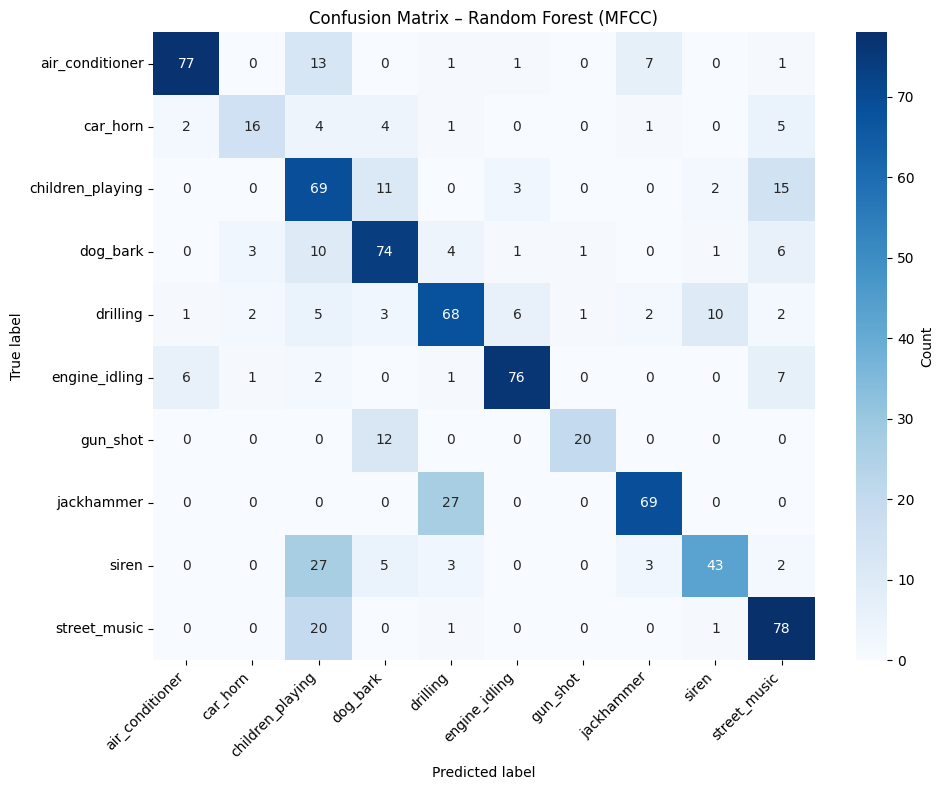

Confusion Matrix – Random Forest (MFCC)
                  precision    recall  f1-score   support

 air_conditioner     0.8953    0.7700    0.8280       100
        car_horn     0.7273    0.4848    0.5818        33
children_playing     0.4600    0.6900    0.5520       100
        dog_bark     0.6789    0.7400    0.7081       100
        drilling     0.6415    0.6800    0.6602       100
   engine_idling     0.8736    0.8172    0.8444        93
        gun_shot     0.9091    0.6250    0.7407        32
      jackhammer     0.8415    0.7188    0.7753        96
           siren     0.7544    0.5181    0.6143        83
    street_music     0.6724    0.7800    0.7222       100

        accuracy                         0.7049       837
       macro avg     0.7454    0.6824    0.7027       837
    weighted avg     0.7318    0.7049    0.7096       837



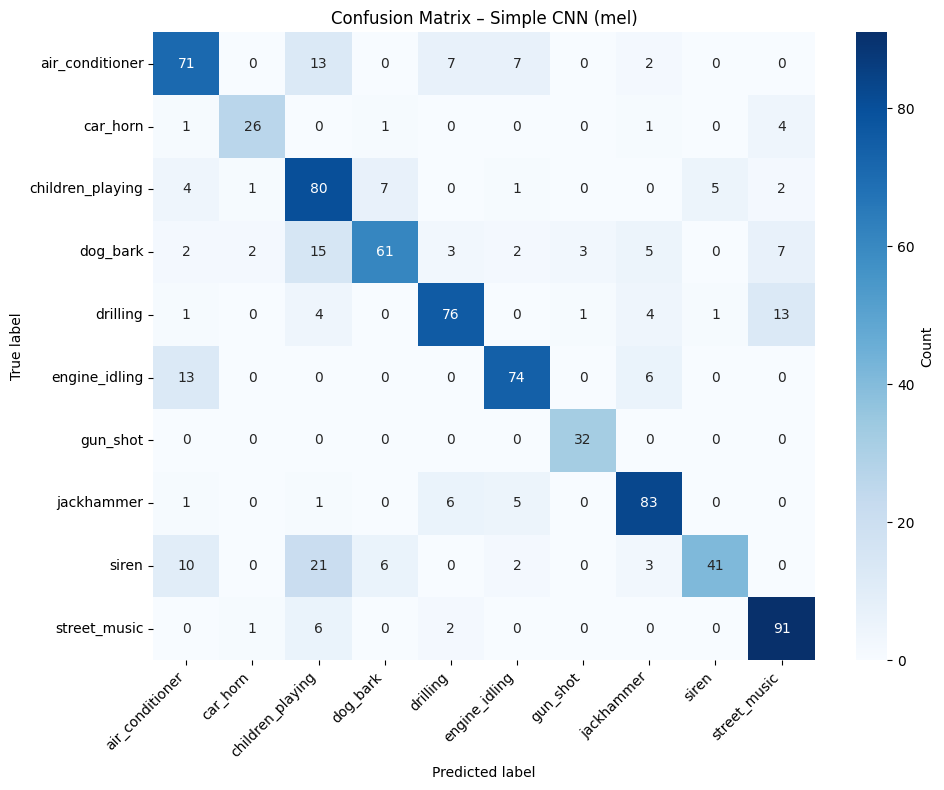

Confusion Matrix – Simple CNN (mel)
                  precision    recall  f1-score   support

 air_conditioner     0.6893    0.7100    0.6995       100
        car_horn     0.8667    0.7879    0.8254        33
children_playing     0.5714    0.8000    0.6667       100
        dog_bark     0.8133    0.6100    0.6971       100
        drilling     0.8085    0.7600    0.7835       100
   engine_idling     0.8132    0.7957    0.8043        93
        gun_shot     0.8889    1.0000    0.9412        32
      jackhammer     0.7981    0.8646    0.8300        96
           siren     0.8723    0.4940    0.6308        83
    street_music     0.7778    0.9100    0.8387       100

        accuracy                         0.7587       837
       macro avg     0.7900    0.7732    0.7717       837
    weighted avg     0.7739    0.7587    0.7560       837



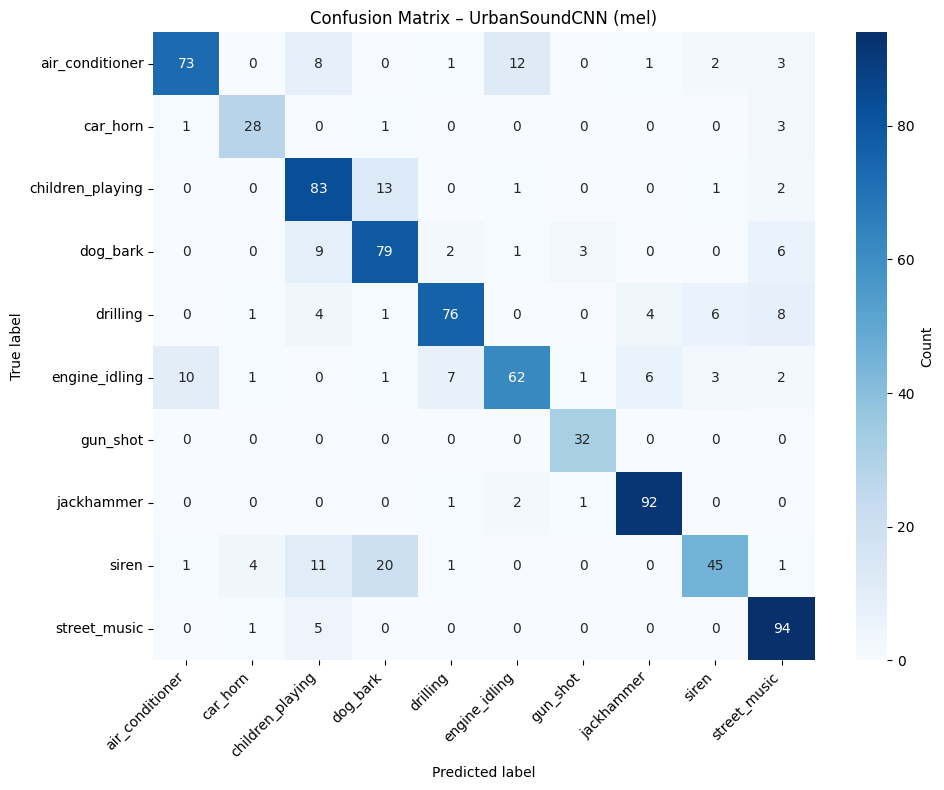

Confusion Matrix – UrbanSoundCNN (mel)
                  precision    recall  f1-score   support

 air_conditioner     0.8588    0.7300    0.7892       100
        car_horn     0.8000    0.8485    0.8235        33
children_playing     0.6917    0.8300    0.7545       100
        dog_bark     0.6870    0.7900    0.7349       100
        drilling     0.8636    0.7600    0.8085       100
   engine_idling     0.7949    0.6667    0.7251        93
        gun_shot     0.8649    1.0000    0.9275        32
      jackhammer     0.8932    0.9583    0.9246        96
           siren     0.7895    0.5422    0.6429        83
    street_music     0.7899    0.9400    0.8584       100

        accuracy                         0.7933       837
       macro avg     0.8033    0.8066    0.7989       837
    weighted avg     0.7985    0.7933    0.7897       837



In [84]:
class_names = global_label_encoder.classes_

def plot_confusion_matrix(all_labels, all_preds, title):
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        cbar_kws={"label": "Count"},
    )
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print(title)
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))
plot_confusion_matrix(all_labels_rf, all_preds_rf, "Confusion Matrix – Random Forest (MFCC)")
plot_confusion_matrix(all_labels_simple, all_preds_simple, "Confusion Matrix – Simple CNN (mel)")
plot_confusion_matrix(all_labels_urban, all_preds_urban, "Confusion Matrix – UrbanSoundCNN (mel)")

### Анализ матриц ошибок и per-class метрик

По общей accuracy и macro f1 сверточные модели заметно превосходят Random Forest:
лес на MFCC достигает около 70% accuracy, CNN-75-80%. Это подтверждает, что
обучение CNN напрямую на мел‑спектрограммах даёт более информативные признаки,
чем ручные MFCC‑вектора для дерева решений.

По отдельным классам UrbanSoundCNN чаще всего показывает лучшие значения f1:
особенно сильно улучшается качество на классах *children_playing* и *street_music*,
а редкий класс *gun_shot* практически идеально распознаётся обеими CNN. При этом
класс *siren* остаётся трудным для всех моделей: precision высокое, но recall
заметно ниже, что говорит о частых пропусках этого типа звуков.

#  Финальная 10-fold оценка 

Класс `CachedUrbanSoundDataset` позволяет повторно использовать уже подготовленные мел-спектрограммы и метки из словарей `mel_cache` и `label_cache`, не пересчитывая их при каждом запуске. По `slice_file_name` выбирается нужный пример, из кэша берётся мел-спектрограмма и соответствующая метка. При включённом флаге `augment` к мел-спектрограмме применяются те же аугментации, что и в базовом датасете: добавление шума, зануление случайных полос по частоте, изменение громкости и сдвиг по времени. Это ускоряет k-fold обучение CNN, так как дорогостоящий шаг извлечени

In [39]:
# Подсчитаем один раз mel для k-fold
full_ds = UrbanSoundDataset(
    metadata=metadata,
    dataset_path=DATASET_PATH,
    label_encoder=global_label_encoder,
    augment=False,
    cache_dir=None, 
)

# Кэш: slice_file_name -> (mel, label)
mel_cache = {}
label_cache = {}

for i in range(len(full_ds)):
    row = metadata.iloc[i]
    key = row["slice_file_name"]  # уникальный ID фрагмента

    mel_cache[key] = full_ds.mels[i]     # тензор (1, n_mels, T)
    label_cache[key] = full_ds.labels[i] 

Preparing mel-spectrograms: 100%|██████████████████████████████████████████████████| 8732/8732 [03:37<00:00, 40.12it/s]


In [40]:
class CachedUrbanSoundDataset(Dataset):
    def __init__(self, df, mel_cache, label_cache, augment=False):
        self.df = df.reset_index(drop=True)
        self.mel_cache = mel_cache
        self.label_cache = label_cache
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def augment_mel(self, mel):
        mel = mel.clone()

        if np.random.rand() < 0.5:
            mel = mel + torch.randn_like(mel) * 0.01

        if np.random.rand() < 0.5:
            f = mel.shape[1]
            rand_freq = np.random.randint(3, 10)
            if f > rand_freq:
                start = np.random.randint(0, f - rand_freq)
                mel[:, start:start + rand_freq, :] = 0

        if np.random.rand() < 0.5:
            scale = np.random.uniform(0.9, 1.1)
            mel = mel * scale

        if np.random.rand() < 0.5:
            shift = np.random.randint(-3, 4)
            mel = torch.roll(mel, shifts=shift, dims=2)

        return mel

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        key = row["slice_file_name"]

        mel = self.mel_cache[key].clone()
        label = self.label_cache[key].clone()

        if self.augment:
            mel = self.augment_mel(mel)

        return mel, label

### 10-fold кросс-валидация с кэшем и общей train‑функцией
Функция `evaluate_10fold` выполняет 10-fold кросс-валидацию по , но вместо пересчёта мел-спектрограмм на лету использует
готовый кэш

In [41]:
def evaluate_10fold(
    model_class,
    model_kwargs,
    train_fn,
    metadata,
    mel_cache,
    label_cache,
    device="cuda",
    verbose=True,
):
    """
    10-fold CV по folds UrbanSound8K, используя готовый кэш мел-спектрограмм
    """
    accuracies = []

    for test_fold in range(1, 11):
        val_fold = 1 if test_fold == 10 else test_fold + 1
        train_folds = [f for f in range(1, 11) if f not in {test_fold, val_fold}]

        if verbose:
            print(f"\n{'=' * 50}")
            print(f"Fold {test_fold}/10 (val={val_fold}, train={train_folds})")

        train_df = metadata[metadata["fold"].isin(train_folds)]
        val_df = metadata[metadata["fold"] == val_fold]
        test_df = metadata[metadata["fold"] == test_fold]

        train_ds = CachedUrbanSoundDataset(train_df, mel_cache, label_cache, augment=True)
        val_ds = CachedUrbanSoundDataset(val_df, mel_cache, label_cache, augment=False)
        test_ds = CachedUrbanSoundDataset(test_df, mel_cache, label_cache, augment=False)

        loader_kwargs = dict(num_workers=0, pin_memory=True)
        train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, **loader_kwargs)
        val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, **loader_kwargs)
        test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, **loader_kwargs)

        model = model_class(**model_kwargs).to(device)
        model = train_fn(model, train_loader, val_loader, device)

        model.eval()
        all_preds, all_labels = [], []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                preds = model(inputs).argmax(1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.numpy())

        acc = np.mean(np.array(all_preds) == np.array(all_labels))
        accuracies.append(acc)

        if verbose:
            print(f"Fold {test_fold} accuracy: {acc * 100:.2f}%")

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    mean_acc = np.mean(accuracies)
    std_acc = np.std(accuracies)

    if verbose:
        print(f"\n{'=' * 50}")
        print(f"10-fold CV: {mean_acc * 100:.2f}% ± {std_acc * 100:.2f}%")

    return accuracies

Функция `my_train_fn` задаёт единый сценарий обучения для любой модели: инициализирует веса, настраивает `CrossEntropyLoss`, оптимизатор `AdamW` и планировщик `ReduceLROnPlateau`. В цикле по эпохам считается train/val loss и accuracy, применяется early stopping по валидационной точности, а лучшая модель по val_acc сохраняется в файл и затем загружается обратно.

In [97]:
def my_train_fn(model, train_loader, val_loader, device):
    model = model.to(device)
    model.apply(init_weights)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
    )

    num_epochs = 20
    patience = 7
    patience_counter = 0
    best_val_acc = 0.0

    model_name = model.__class__.__name__
    best_model_path = f"best_{model_name}_kfold.pth"

    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = validate(
            model, val_loader, criterion, device
        )

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"[{model_name}] Epoch {epoch + 1}/{num_epochs} | "
            f"lr={current_lr:.6f} | "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"[{model_name}] Early stopping")
                break

    model.load_state_dict(torch.load(best_model_path, map_location=device))
    return model

In [44]:
# k-fold для SimpleUrbanSoundCNN
accuracies_simple = evaluate_10fold(
    model_class=SimpleUrbanSoundCNN,
    model_kwargs={"num_classes": 10},
    train_fn=my_train_fn,
    metadata=metadata,
    mel_cache=mel_cache,
    label_cache=label_cache,
    device=device,
)


Fold 1/10 (val=2, train=[3, 4, 5, 6, 7, 8, 9, 10])
Epoch 1/20 | train_loss=1.9916 | train_acc=0.3130 | val_loss=1.8055 | val_acc=0.4189
Epoch 2/20 | train_loss=1.5686 | train_acc=0.4633 | val_loss=1.4816 | val_acc=0.3998
Epoch 3/20 | train_loss=1.3769 | train_acc=0.5273 | val_loss=1.4447 | val_acc=0.5203
Epoch 4/20 | train_loss=1.2420 | train_acc=0.5830 | val_loss=1.3932 | val_acc=0.4707
Epoch 5/20 | train_loss=1.1388 | train_acc=0.6133 | val_loss=1.2519 | val_acc=0.4977
Epoch 6/20 | train_loss=1.0684 | train_acc=0.6309 | val_loss=1.2335 | val_acc=0.4764
Epoch 7/20 | train_loss=1.0144 | train_acc=0.6587 | val_loss=1.4136 | val_acc=0.5360
Epoch 8/20 | train_loss=0.9724 | train_acc=0.6744 | val_loss=1.0948 | val_acc=0.5957
Epoch 9/20 | train_loss=0.9389 | train_acc=0.6871 | val_loss=1.1794 | val_acc=0.5113
Epoch 10/20 | train_loss=0.8954 | train_acc=0.7054 | val_loss=1.2292 | val_acc=0.5676
Epoch 11/20 | train_loss=0.8679 | train_acc=0.7185 | val_loss=1.2346 | val_acc=0.5450
Epoch 12/20

In [46]:
# k-fold для UrbanSoundCNN
accuracies_cnn = evaluate_10fold(
    model_class=UrbanSoundCNN,
    model_kwargs={"num_classes": 10},
    train_fn=my_train_fn,
    metadata=metadata,
    mel_cache=mel_cache,
    label_cache=label_cache,
    device=device,
)


Fold 1/10 (val=2, train=[3, 4, 5, 6, 7, 8, 9, 10])
[UrbanSoundCNN] Epoch 1/20 | lr=0.001000 | train_loss=1.8655 | train_acc=0.2624 | val_loss=2.0691 | val_acc=0.2793
[UrbanSoundCNN] Epoch 2/20 | lr=0.001000 | train_loss=1.3659 | train_acc=0.4639 | val_loss=1.6462 | val_acc=0.4358
[UrbanSoundCNN] Epoch 3/20 | lr=0.001000 | train_loss=1.0946 | train_acc=0.5966 | val_loss=1.9431 | val_acc=0.3288
[UrbanSoundCNN] Epoch 4/20 | lr=0.001000 | train_loss=0.9123 | train_acc=0.6907 | val_loss=1.5046 | val_acc=0.5124
[UrbanSoundCNN] Epoch 5/20 | lr=0.001000 | train_loss=0.7791 | train_acc=0.7395 | val_loss=1.7182 | val_acc=0.4876
[UrbanSoundCNN] Epoch 6/20 | lr=0.001000 | train_loss=0.6707 | train_acc=0.7771 | val_loss=1.3363 | val_acc=0.5439
[UrbanSoundCNN] Epoch 7/20 | lr=0.001000 | train_loss=0.5770 | train_acc=0.8127 | val_loss=1.4444 | val_acc=0.5687
[UrbanSoundCNN] Epoch 8/20 | lr=0.001000 | train_loss=0.5022 | train_acc=0.8345 | val_loss=1.5959 | val_acc=0.5495
[UrbanSoundCNN] Epoch 9/20 |

In [47]:
mean_simple = np.mean(accuracies_simple)
std_simple = np.std(accuracies_simple)

mean_cnn = np.mean(accuracies_cnn)
std_cnn = np.std(accuracies_cnn)

print(f"Simple CNN 10-fold: {mean_simple*100:.2f}% ± {std_simple*100:.2f}%")
print(f"UrbanSoundCNN 10-fold: {mean_cnn*100:.2f}% ± {std_cnn*100:.2f}%")

Simple CNN 10-fold: 65.36% ± 4.05%
UrbanSoundCNN 10-fold: 70.52% ± 3.90%


| Модель           | Оценка          | Mean accuracy | Std    | Примечание                        |
|------------------|-----------------|---------------|--------|-----------------------------------|
| Simple CNN       | 10-fold CV      | 65.36%        | 4.05%  | evaluate_10fold, mel-спектрограмма|
| UrbanSoundCNN    | 10-fold CV      | 70.52%        | 3.90%  | evaluate_10fold, mel-спектрограмма|

Для сверточных моделей была проведена 10‑fold кросс‑валидация. Простая свёрточная сеть на мел‑спектрограммах показала 65.36% $\pm$ 4.05%, а более сложная UrbanSoundCNN достигла 70.52% $\pm$ 3.90%, что демонстрирует устойчивый выигрыш глубокой CNN над облегчённой.

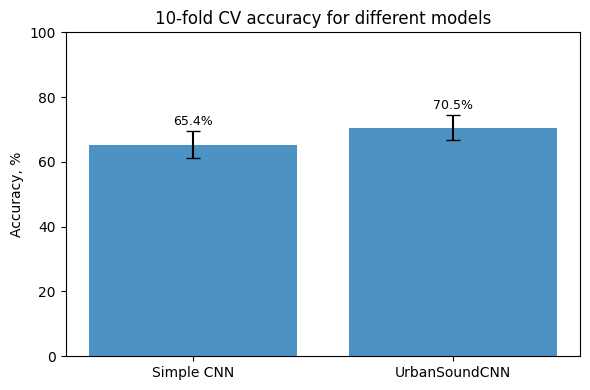

In [104]:
model_names = [ "Simple CNN", "UrbanSoundCNN"]
mean_accs = [ 0.6536, 0.7052]
std_accs = [ 0.0405, 0.0390] 

plt.figure(figsize=(6, 4))
bars = plt.bar(model_names, [m * 100 for m in mean_accs],
               yerr=[s * 100 for s in std_accs],
               capsize=5, alpha=0.8)

plt.ylabel("Accuracy, %")
plt.title("10-fold CV accuracy for different models")

for bar, acc in zip(bars, mean_accs):
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 5,
             f"{acc*100:.1f}%", ha="center", va="bottom", fontsize=9)

plt.ylim(0, 100)
plt.tight_layout()
plt.show()